...in this one we run an updated version of the py code the py code used until 4 is `run_llama_drops_fix_test copy 2.py` ...

Main Updates: High-Precision Occupation Matcher
The script has transitioned from a simple similarity tool to a robust classification auditor.

1. Logical "Anchor" Framework
The Rule: The model now identifies Candidate 1 as the "Anchor" (the best embedding match).

The Constraint: It is forbidden from dropping the anchor unless the job tasks explicitly contradict it, preventing "label-hopping."

2. Hardened IT Gatekeeping
The Shield: Explicit instructions prevent "IT Leakage" by distinguishing between using tools (Excel, SAP, CRM) and building them (coding, APIs, pipelines).

Result: Significantly higher precision for the AISI Economy Index.

3. Bulletproof JSON Extraction
Bracket Scanning: Replaced regex with a depth-tracking bracket scanner (extract_last_json_object) to catch JSON even if the model adds conversational "stutter."

Pydantic Validation: Uses a strict schema to reject malformed or extra keys automatically.

4. Precision Fallbacks
Self-Correction: If the model tries to drop all candidates or the output fails to parse, the script defaults to keeping only the Anchor.

Consistency: do_sample=False ensures identical job ads always produce identical pruning results.

5. Cluster Optimizations
Efficiency: Batch size (128) and token limit (80) are tuned for Isambard-AI's GPU memory.

Audit Metrics: Real-time tracking of parse_fail_rate and forced_anchor_rate in the logs.

# Helpers

In [3]:
import json
import re
import random
import statistics
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime

import numpy as np

# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------
_RUN_RE = re.compile(
    r"llama_drop_only_(?P<month>adzuna_month\d{2})_(?P<start>\d+)_(?P<stop>\d+)_job(?P<jobid>\d+)_task(?P<taskid>\d+)_\d{8}_\d{6}\.jsonl$"
)

IT_PATTERNS = [
    r"\bsoftware\b", r"\bdeveloper\b", r"\bengineer\b", r"\bdata\b", r"\bml\b", r"\bai\b",
    r"\bcloud\b", r"\bcyber\b", r"\bsecurity\b", r"\bnetwork\b", r"\bsystems?\b",
    r"\bdatabase\b", r"\bit\b", r"\bdevops\b"
]
_IT_RE = re.compile("|".join(IT_PATTERNS), flags=re.I)

def _is_it_role(title: str) -> bool:
    if not title:
        return False
    return bool(_IT_RE.search(title))


def _infer_npz_from_jsonl(jsonl_path: Path) -> Path:
    """
    NEW layout:
      .../llm_negative_selection/<EMBED>/<adzuna_monthXX>/llama_drop_only_....jsonl
    NPZ sits at:
      .../llm_negative_selection/<EMBED>/<adzuna_monthXX>.npz
    """
    m = _RUN_RE.search(jsonl_path.name)
    if not m:
        raise ValueError(f"JSONL filename doesn't match expected pattern: {jsonl_path.name}")

    month = m.group("month")
    embed_root = jsonl_path.parent.parent  # .../llm_negative_selection/<EMBED>
    return embed_root / f"{month}.npz"


def _get_job_ids(z) -> np.ndarray:
    """
    Supports both schemas:
      new: job_ids
      old: job_id
    Returns np.ndarray[str]
    """
    if "job_ids" in z.files:
        return z["job_ids"].astype(str)
    if "job_id" in z.files:
        return z["job_id"].astype(str)
    raise KeyError(f"NPZ missing job id key. Need job_ids or job_id. Have={sorted(z.files)}")


def _load_npz_lookup(npz_path: Path):
    """
    Expects stage3-prep NPZ keys (canonical):
      job_ids (or job_id), job_ad_title, job_desc, job_tasks, domain, job_sector_category, job_description
    """
    with np.load(npz_path, allow_pickle=True) as z:
        job_ids = _get_job_ids(z)

        # canonical (your stage3-prep)
        job_ad_title = z["job_ad_title"]
        job_desc = z["job_desc"]
        job_tasks = z["job_tasks"]

        domain = z["domain"] if "domain" in z.files else None
        job_sector_category = z["job_sector_category"] if "job_sector_category" in z.files else None
        job_description = z["job_description"] if "job_description" in z.files else None

    lookup = {}
    for i, jid in enumerate(job_ids):
        lookup[jid] = {
            "job_ad_title": None if job_ad_title[i] is None else str(job_ad_title[i]),
            "job_desc": None if job_desc[i] is None else str(job_desc[i]),
            "job_tasks": None if job_tasks[i] is None else str(job_tasks[i]),
            "job_description": None if job_description is None or job_description[i] is None else str(job_description[i]),
            "domain": None if domain is None or domain[i] is None else str(domain[i]),
            "job_sector_category": None if job_sector_category is None or job_sector_category[i] is None else str(job_sector_category[i]),
        }
    return lookup


# ---------------------------------------------------------------------
# Main: report generator
# ---------------------------------------------------------------------
def gen_report(jsonl_path: str, *, npz_path: str | None = None, sample_n: int = 30, seed: int = 0):
    """
    jsonl_path: path to llama_drop_only_*.jsonl
    npz_path  : optional explicit context NPZ. If None, inferred from jsonl name/dir.
    """
    random.seed(seed)

    jsonl_path = Path(jsonl_path)
    if not jsonl_path.exists():
        raise FileNotFoundError(f"Missing JSONL: {jsonl_path}")

    inferred_npz = _infer_npz_from_jsonl(jsonl_path)
    npz_path = Path(npz_path) if npz_path else inferred_npz
    if not npz_path.exists():
        raise FileNotFoundError(f"Missing NPZ: {npz_path}")

    # report folder: put it under .../llm_negative_selection/<EMBED>/evaluation_reports/
    embed_root = jsonl_path.parent.parent  # .../llm_negative_selection/<EMBED>
    report_dir = embed_root / "evaluation_reports"
    report_dir.mkdir(parents=True, exist_ok=True)

    print("JSONL:", jsonl_path)
    print("NPZ :", npz_path)
    print("OUT :", report_dir)

    lookup = _load_npz_lookup(npz_path)

    before_counts = []
    after_counts = []
    kept_titles = Counter()
    domain_kept = defaultdict(list)

    it_leak = 0
    total_kept = 0
    empty_outputs = 0

    samples = []
    seen_sample_ids = set()

    with jsonl_path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            try:
                r = json.loads(line)
            except Exception:
                continue

            jid = str(r.get("job_id", "")).strip()
            if not jid:
                continue

            ctx = lookup.get(jid, {})

            cand = r.get("candidates") or []
            final = r.get("final") or []

            before_counts.append(len(cand))
            after_counts.append(len(final))

            if len(final) == 0:
                empty_outputs += 1

            for t in final:
                kept_titles[t] += 1
                total_kept += 1
                if _is_it_role(t):
                    it_leak += 1

            dom = ctx.get("domain") or "UNKNOWN"
            domain_kept[dom].append(len(final))

            # sample gate
            if len(samples) < sample_n and jid not in seen_sample_ids and random.random() < 0.05:
                seen_sample_ids.add(jid)
                samples.append({
                    "job_id": jid,
                    "job_ad_title": ctx.get("job_ad_title"),
                    "domain": ctx.get("domain"),
                    "sector": ctx.get("job_sector_category"),
                    "job_desc": ctx.get("job_desc"),
                    "kept": final,
                    "dropped": r.get("drop") or [],
                })

    if not before_counts:
        raise RuntimeError("No valid rows parsed from JSONL.")

    before_avg = statistics.mean(before_counts)
    after_avg = statistics.mean(after_counts)
    drop_rate = 1.0 - (after_avg / before_avg if before_avg else 0.0)
    it_share = it_leak / max(total_kept, 1)

    metrics = {
        "jobs": len(before_counts),
        "avg_candidates_before": round(before_avg, 3),
        "avg_candidates_after": round(after_avg, 3),
        "drop_rate": round(drop_rate, 4),
        "empty_outputs_percent": round(100.0 * empty_outputs / len(before_counts), 3),
        "it_leakage_share": round(it_share, 4),
        "min_kept": int(min(after_counts)),
        "max_kept": int(max(after_counts)),
    }

    domain_summary = {d: round(statistics.mean(v), 3) for d, v in domain_kept.items()}

    report = {
        "run": {
            "jsonl": str(jsonl_path),
            "npz": str(npz_path),
            "generated_at": datetime.now().isoformat(timespec="seconds"),
        },
        "global_metrics": metrics,
        "top_kept_roles": kept_titles.most_common(25),
        "domain_summary_avg_kept": dict(sorted(domain_summary.items(), key=lambda x: (-x[1], x[0]))),
        "sample_cases": samples,
    }

    base = jsonl_path.stem
    report_json = report_dir / f"{base}_report.json"
    report_txt = report_dir / f"{base}_report.txt"

    with report_json.open("w", encoding="utf-8") as f:
        json.dump(report, f, indent=2, ensure_ascii=False)

    with report_txt.open("w", encoding="utf-8") as f:
        f.write("=== GLOBAL METRICS ===\n")
        for k, v in metrics.items():
            f.write(f"{k}: {v}\n")

        f.write("\n=== TOP KEPT OCCUPATIONS ===\n")
        for title, cnt in kept_titles.most_common(25):
            f.write(f"{cnt}  {title}\n")

        f.write("\n=== DOMAIN AVG KEPT ===\n")
        for d, v in sorted(domain_summary.items(), key=lambda x: (-x[1], x[0])):
            f.write(f"{d}: {v}\n")

        f.write("\n=== SAMPLE CASES (truncated) ===\n")
        for s in samples[:10]:
            f.write(f"\njob_id: {s['job_id']}\n")
            f.write(f"title:  {s.get('job_ad_title')}\n")
            f.write(f"domain: {s.get('domain')} | sector: {s.get('sector')}\n")
            f.write(f"kept:   {s.get('kept')}\n")
            f.write(f"drop:   {s.get('dropped')}\n")

    print("\nSaved:")
    print(" ", report_json)
    print(" ", report_txt)

    return report_json, report_txt


# Prompt 4 - A bit less strict than prompt 3

In [2]:
# ===== Prompt printer: OCCUPATION MATCHER (E5 Production - Upgraded) =====

import numpy as np
from pathlib import Path

# ---- CONFIG ----
NPZ_PATH = Path("/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/e5_large/adzuna_month01.npz")
ROW_IDX = 35  # Inspect any sample row

# ---- LOAD ----
data = np.load(NPZ_PATH, allow_pickle=True)

# Map NPZ keys to variables
job_ad_title = data["job_ad_title"][ROW_IDX]
domain = data["domain"][ROW_IDX]
job_sector_category = data["job_sector_category"][ROW_IDX]
job_desc = data["job_desc"][ROW_IDX]
job_tasks = data["job_tasks"][ROW_IDX]
job_full_ads = data["job_description"][ROW_IDX]
row_candidates = data["titles"][ROW_IDX]

# Clean up tasks/evidence string
if isinstance(job_tasks, (list, np.ndarray)):
    tasks_str = ", ".join([str(t) for t in job_tasks if t])
else:
    tasks_str = str(job_tasks)

# Format candidates as a 1-based numbered list
numbered = "\n".join([f"{i+1}. {cand}" for i, cand in enumerate(row_candidates) if cand])

# ---- BUILD PROMPT (Upgraded Expert Version) ----

# Slicing the full text for the excerpt block
full_excerpt = str(job_full_ads).strip()[:700] if job_full_ads else ""
full_block = (
    f"\nFULL AD EXCERPT (only for concrete duties, tools, licences; ignore fluff):\n{full_excerpt}\n"
    if full_excerpt else ""
)

prompt = f"""
You are an expert Labor Economist and Occupation Matcher.

Your task is to evaluate the candidate occupations and DROP those that are not functional matches for the Job Context.

### OBJECTIVE
- Default outcome: keep EXACTLY ONE best match.
- Maximum: keep up to 3 ONLY if the job clearly combines distinct functions (for example: Driver/Sales or Manager + Technical role).
- If uncertain, DROP. Precision is more important than recall for this task.

### JOB CONTEXT
Title: {job_ad_title}
Sector/Domain: {job_sector_category} | {domain}
Core Evidence: {tasks_str} {job_desc}

Secondary Evidence:
{full_block}

### CANDIDATES (1-based)
{numbered}

### ANCHOR REQUIREMENT
First select ONE candidate as the ANCHOR (the best overall functional match).

Assume the anchor is correct by default.
Change the anchor only if the tasks clearly contradict it.
A contradiction requires explicit task evidence, not similarity or wording overlap.

### CRITICAL PRUNING RULES
1. FUNCTION OVER TITLE  
   If the title suggests seniority or management but the tasks reflect operational work, match the operational occupation.

2. SPECIFICITY WINNER  
   When both a specialist and a generic parent occupation exist, keep the specialist and drop the generic one.

3. PRIMARY ROLE BIAS  
   Most jobs correspond to one occupation. Keep multiple candidates only when tasks clearly show separate functions.

4. IT GATEKEEPER  
   Drop all IT/Software/Data occupations unless the job explicitly involves coding, software development, system architecture, pipelines, APIs, or model building.  
   Using tools such as Excel, SAP, CRM, or dashboards is NOT sufficient.

5. ANCHOR STABILITY  
   Do not switch between similar occupations unless there is clear task evidence that the anchor is incorrect.

### OUTPUT FORMAT
Return ONLY valid JSON with exactly this key:
{{"drop":[...]}}
""".strip()

# ---- PRINT ----
print("-" * 30)
print(f"VERIFIED UPGRADED PRODUCTION PROMPT (ROW {ROW_IDX}):")
print("-" * 30)
print(prompt)
print("-" * 30)

------------------------------
VERIFIED UPGRADED PRODUCTION PROMPT (ROW 35):
------------------------------
You are an expert Labor Economist and Occupation Matcher.

Your task is to evaluate the candidate occupations and DROP those that are not functional matches for the Job Context.

### OBJECTIVE
- Default outcome: keep EXACTLY ONE best match.
- Maximum: keep up to 3 ONLY if the job clearly combines distinct functions (for example: Driver/Sales or Manager + Technical role).
- If uncertain, DROP. Precision is more important than recall for this task.

### JOB CONTEXT
Title: Sommelier-Restaurant Gordon Ramsay
Sector/Domain: Hospitality & Catering Jobs | Hospitality & Catering
Core Evidence: [Hospitality & Catering] Assist the Head Sommelier with wine and beverage service Supervise setting up and clearing down after each service Recommend and sell wines to guests Engage with customers to deliver high levels of service Supervise wine and beverage service WSET certification Wine knowledg

## bge

In [3]:
import subprocess, re
from pathlib import Path

SBATCH = Path("/projects/a5u/adu_dev/aisi-economy-index/nbs/AISI_demo/Stage_3_negative_selection/dev/sbatch/run_llama_drop_bge.sbatch")
assert SBATCH.exists(), f"Missing sbatch file: {SBATCH}"

out = subprocess.check_output(["sbatch", str(SBATCH)], text=True)
jobid = re.search(r"(\d+)", out).group(1)
print("JOBID:", jobid)
bge_jobid = jobid

JOBID: 2167537


## e5

In [4]:
import subprocess, re
from pathlib import Path

SBATCH = Path("/projects/a5u/adu_dev/aisi-economy-index/nbs/AISI_demo/Stage_3_negative_selection/dev/sbatch/run_llama_drop_e5.sbatch")
assert SBATCH.exists(), f"Missing sbatch file: {SBATCH}"

out = subprocess.check_output(["sbatch", str(SBATCH)], text=True)
jobid = re.search(r"(\d+)", out).group(1)
print("JOBID:", jobid)
e5_jobid = jobid

JOBID: 2167538


## gte

In [5]:
import subprocess, re
from pathlib import Path

SBATCH = Path("/projects/a5u/adu_dev/aisi-economy-index/nbs/AISI_demo/Stage_3_negative_selection/dev/sbatch/run_llama_drop_gte.sbatch")
assert SBATCH.exists(), f"Missing sbatch file: {SBATCH}"

out = subprocess.check_output(["sbatch", str(SBATCH)], text=True)
jobid = re.search(r"(\d+)", out).group(1)
print("JOBID:", jobid)
gte_jobid = jobid

JOBID: 2167539


In [6]:
# monitoring

In [6]:
import time, subprocess
from pathlib import Path
jobid= 2167539
LOG_DIR = Path("/projects/a5u/adu_dev/aisi-economy-index/logs")
def sh(cmd):
    return subprocess.run(cmd, shell=True, text=True, capture_output=True).stdout.strip()
while True:
    print("\n=== squeue ===")
    sq = sh(f"squeue -j {jobid}")
    print(sq if sq else "<finished>")

    out_logs = sorted(LOG_DIR.glob(f"*{jobid}*.out"))
    err_logs = sorted(LOG_DIR.glob(f"*{jobid}*.err"))

    if out_logs:
        print("\n--- STDOUT ---")
        print(sh(f"tail -n 20 {out_logs[-1]}"))

    if err_logs:
        print("\n--- STDERR ---")
        print(sh(f"tail -n 20 {err_logs[-1]}"))

    if not sq:
        break

    time.sleep(5)



=== squeue ===
JOBID         USER PARTITION                     NAME ST TIME_LIMIT       TIME  TIME_LEFT NODES NODELIST(REASON)
2167539 autonomyluiz     workq z_llama_drop_new_test_gt PD    6:00:00       0:00    6:00:00     1 (Priority)

=== squeue ===
JOBID         USER PARTITION                     NAME ST TIME_LIMIT       TIME  TIME_LEFT NODES NODELIST(REASON)
2167539 autonomyluiz     workq z_llama_drop_new_test_gt PD    6:00:00       0:00    6:00:00     1 (Priority)

=== squeue ===
JOBID         USER PARTITION                     NAME ST TIME_LIMIT       TIME  TIME_LEFT NODES NODELIST(REASON)
2167539 autonomyluiz     workq z_llama_drop_new_test_gt PD    6:00:00       0:00    6:00:00     1 (Priority)

=== squeue ===
JOBID         USER PARTITION                     NAME ST TIME_LIMIT       TIME  TIME_LEFT NODES NODELIST(REASON)
2167539 autonomyluiz     workq z_llama_drop_new_test_gt PD    6:00:00       0:00    6:00:00     1 (Priority)

=== squeue ===
JOBID         USER PARTITION    

KeyboardInterrupt: 

In [10]:
bge_jobid, e5_jobid, gte_jobid = 2167537,2167538,2167539

In [11]:
import time, subprocess
from pathlib import Path

for jobid in [bge_jobid, e5_jobid, gte_jobid]:
    LOG_DIR = Path("/projects/a5u/adu_dev/aisi-economy-index/logs")
    
    DONE_TAG = "DONE] wrote:"
    
    def sh(cmd: str) -> str:
        return subprocess.run(cmd, shell=True, text=True, capture_output=True).stdout
    
    def tail(path: Path, n: int = 80) -> str:
        return sh(f"tail -n {n} {path}")
    
    def latest_log(jobid: int, suffix: str) -> Path | None:
        logs = sorted(LOG_DIR.glob(f"*{jobid}*{suffix}"))
        return logs[-1] if logs else None
    
    seen = set()
    
    import time
    
    done_path = None
    
    while True:
        out_log = latest_log(jobid, ".out")
    
        if out_log and out_log.exists():
            chunk = tail(out_log, 120)
            for line in chunk.splitlines():
                if DONE_TAG in line:
                    done_path = line.split(DONE_TAG, 1)[1].strip()
                    print(f"[DONE] {done_path}")
                    break
    
            if done_path:
                break
    
        time.sleep(5)
    
    
    done_path
    print('**'*50)



[DONE] /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2167537_task0_20260205_174331.jsonl
****************************************************************************************************
[DONE] /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/e5_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2167538_task0_20260205_174613.jsonl
****************************************************************************************************
[DONE] /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/gte_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2167539_task0_20260205_174858.jsonl
****************************************************************************************************


## Results comparison


--- BGE ---
JSONL: /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2167537_task0_20260205_174331.jsonl
NPZ : /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01.npz
OUT : /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/evaluation_reports

Saved:
  /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/evaluation_reports/llama_drop_only_adzuna_month01_0_1000_job2167537_task0_20260205_174331_report.json
  /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/evaluation_reports/llama_drop_only_adzuna_month01_0_1000_job2167537_task0_20260205_174331_report.txt

--- E5 ---
JSONL:

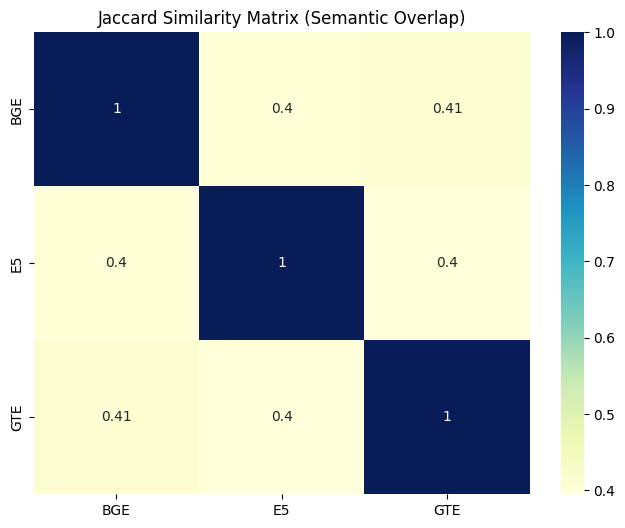

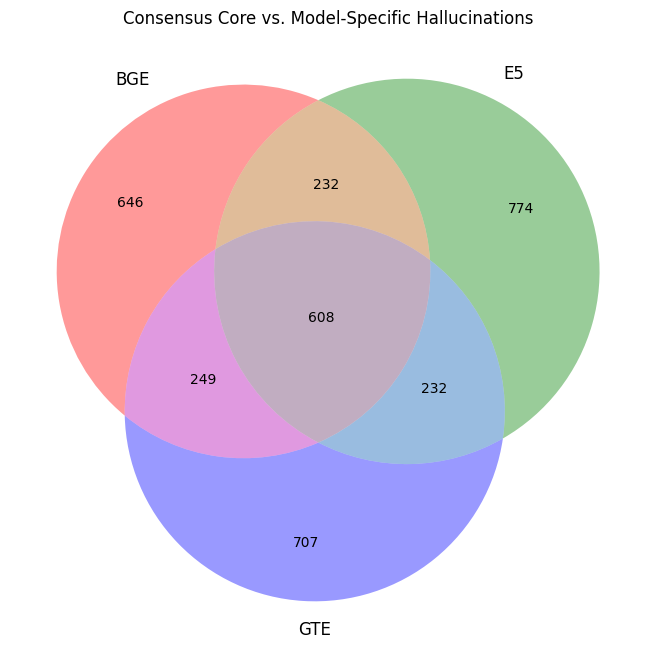

In [12]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn3
from pathlib import Path

# ---- CONFIG ----
BASE_DIR = Path("/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection")

# 1. Define once (Update these only)
PATHS = {
    "BGE": BASE_DIR / "bge_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2167537_task0_20260205_174331.jsonl",
    "E5":  BASE_DIR / "e5_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2167538_task0_20260205_174613.jsonl",
    "GTE": BASE_DIR / "gte_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2167539_task0_20260205_174858.jsonl"
}

# 2. Run reports automatically for each
for model_name, file_path in PATHS.items():
    print(f"\n--- {model_name} ---")
    if file_path.exists():
        gen_report(str(file_path))
    else:
        print(f"Error: File for {model_name} not found at {file_path}")
def load_data(filepath):
    data = {}
    if not filepath.exists(): return data
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            obj = json.loads(line)
            data[obj['job_id']] = set(obj['final'])
    return data

# 1. Load and Intersect
results = {name: load_data(path) for name, path in PATHS.items()}
loaded = [n for n, d in results.items() if d]
common_ids = set.intersection(*[set(results[m].keys()) for m in loaded])

# 2. Extract Commonalities and Differences
report_data = []
for jid in common_ids:
    bge_set = results["BGE"].get(jid, set())
    e5_set = results["E5"].get(jid, set())
    gte_set = results["GTE"].get(jid, set())
    
    # Are they identical?
    all_agree = (bge_set == e5_set == gte_set)
    
    # Who is the outlier?
    outlier = "None"
    if bge_set == e5_set != gte_set: outlier = "GTE"
    elif bge_set == gte_set != e5_set: outlier = "E5"
    elif e5_set == gte_set != bge_set: outlier = "BGE"
    elif not all_agree: outlier = "All Diverged"

    report_data.append({
        "job_id": jid,
        "all_agree": all_agree,
        "outlier": outlier,
        "bge_count": len(bge_set),
        "e5_count": len(e5_set),
        "gte_count": len(gte_set),
        "consensus_count": len(bge_set & e5_set & gte_set)
    })

df = pd.DataFrame(report_data)

# 3. Print Statistical Summary
print("=== COMPREHENSIVE COMPARISON REPORT ===")
print(f"Total Common Jobs: {len(df)}")
print(f"Absolute Consensus: {df['all_agree'].sum()} ({df['all_agree'].mean():.1%})")
print("\n--- Outlier Frequency (Who disagrees with the majority?) ---")
print(df[df['outlier'] != "None"]['outlier'].value_counts())

# 4. Generate Visualizations
# Jaccard Heatmap
model_names = list(results.keys())
j_matrix = np.zeros((3, 3))
for i, m1 in enumerate(model_names):
    for j, m2 in enumerate(model_names):
        scores = [len(results[m1][jid] & results[m2][jid]) / len(results[m1][jid] | results[m2][jid]) 
                  for jid in common_ids]
        j_matrix[i, j] = np.mean(scores)

plt.figure(figsize=(8, 6))
sns.heatmap(j_matrix, annot=True, xticklabels=model_names, yticklabels=model_names, cmap="YlGnBu")
plt.title("Jaccard Similarity Matrix (Semantic Overlap)")
plt.savefig("semantic_overlap_heatmap.png")

# Venn Diagram
venn_sets = []
for name in model_names:
    s = set()
    for jid in common_ids:
        for occ in results[name][jid]:
            s.add(f"{jid}|{occ}")
    venn_sets.append(s)

plt.figure(figsize=(10, 8))
venn3(venn_sets, set_labels=model_names)
plt.title("Consensus Core vs. Model-Specific Hallucinations")
plt.savefig("assignment_venn.png")

In [13]:
from pathlib import Path

# 1. Define your specific report files once
REPORTS = {
    "BGE_LARGE": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/evaluation_reports/llama_drop_only_adzuna_month01_0_1000_job2167537_task0_20260205_174331_report.txt",
    "E5_LARGE":  "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/e5_large/evaluation_reports/llama_drop_only_adzuna_month01_0_1000_job2167538_task0_20260205_174613_report.txt",
    "GTE_LARGE": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/gte_large/evaluation_reports/llama_drop_only_adzuna_month01_0_1000_job2167539_task0_20260205_174858_report.txt"
}

# 2. Loop through and print with clear headers
for model_name, file_path in REPORTS.items():
    p = Path(file_path)
    
    # Visual Header for scannability
    print("\n" + "="*60)
    print(f"****** {model_name} ******")
    print("="*60)
    
    if p.exists():
        print(p.read_text())
    else:
        print(f"FILE NOT FOUND: {file_path}")


****** BGE_LARGE ******
=== GLOBAL METRICS ===
jobs: 1000
avg_candidates_before: 8.221
avg_candidates_after: 1.735
drop_rate: 0.789
empty_outputs_percent: 0.0
it_leakage_share: 0.0784
min_kept: 1
max_kept: 3

=== TOP KEPT OCCUPATIONS ===
37  Information Technology Project Managers
34  Personal Care Aides
27  Customer Service Representatives
27  Sales Managers
25  Software Developers
24  Financial Managers
21  Teaching Assistants, Special Education
18  First-Line Supervisors of Retail Sales Workers
17  Chefs and Head Cooks
17  Food Service Managers
17  Public Relations Specialists
16  Computer Systems Engineers/Architects
15  Administrative Services Managers
15  Advertising and Promotions Managers
15  Acute Care Nurses
14  Human Resources Specialists
14  Marketing Managers
14  Construction Managers
13  Market Research Analysts and Marketing Specialists
13  Medical and Health Services Managers
13  Accountants and Auditors
13  Treasurers and Controllers
13  Architectural and Engineering 

In [16]:
notebook_name = "05_prompt"

In [17]:
import json
import sys
from pathlib import Path
import numpy as np
import pandas as pd

# 1. EXACT CONFIGURATION
PATHS = {
    "BGE": {
        "jsonl": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2167537_task0_20260205_174331.jsonl",
        "npz": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01.npz",
    },
    "E5": {
        "jsonl": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/e5_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2167538_task0_20260205_174613.jsonl",
        "npz": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/e5_large/adzuna_month01.npz",
    },
    "GTE": {
        "jsonl": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/gte_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2167539_task0_20260205_174858.jsonl",
        "npz": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/gte_large/adzuna_month01.npz",
    },
}

# 2. HELPER FUNCTIONS
def _to_str_array(x: np.ndarray) -> np.ndarray:
    if x.dtype == object:
        return np.array([v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else str(v) for v in x])
    if np.issubdtype(x.dtype, np.bytes_):
        return np.array([v.decode("utf-8") for v in x])
    return x.astype(str)

def load_meta_from_npz(npz_path: str) -> pd.DataFrame:
    with np.load(npz_path, allow_pickle=True) as npz:
        job_id_key = "job_id" if "job_id" in npz.files else ("job_ids" if "job_ids" in npz.files else None)
        title_key = "job_ad_title" if "job_ad_title" in npz.files else ("title" if "title" in npz.files else None)
        domain_key = "domain" if "domain" in npz.files else None
        sector_key = "job_sector_category" if "job_sector_category" in npz.files else None

        meta = {
            "job_id": _to_str_array(npz[job_id_key]),
            "title": _to_str_array(npz[title_key]),
        }
        meta["domain"] = _to_str_array(npz[domain_key]) if domain_key else ""
        meta["sector"] = _to_str_array(npz[sector_key]) if sector_key else ""
    return pd.DataFrame(meta)

def load_results_from_jsonl(jsonl_path: str) -> pd.DataFrame:
    rows = []
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line: continue
            try: rows.append(json.loads(line))
            except: continue

    df = pd.DataFrame(rows)
    df["job_id"] = df["job_id"].astype(str)

    if "final" in df.columns: df = df.rename(columns={"final": "kept"})
    if "drop" in df.columns: df = df.rename(columns={"drop": "dropped"})
    
    if "kept" not in df.columns: df["kept"] = None
    if "dropped" not in df.columns: df["dropped"] = None

    def _list_to_csv(x):
        if isinstance(x, list): return ", ".join(map(str, x))
        return "" if x is None else str(x)

    df["kept"] = df["kept"].apply(_list_to_csv)
    df["dropped"] = df["dropped"].apply(_list_to_csv)
    return df[["job_id", "kept", "dropped"]]

# 3. CORE BUILDER
def build_audit_dataset(paths_by_model: dict, n_jobs_per_model: int = 100, seed: int = 42) -> pd.DataFrame:
    all_frames = []
    for model, p in paths_by_model.items():
        print(f"Lendo dados para {model}...")
        meta = load_meta_from_npz(p["npz"])
        res = load_results_from_jsonl(p["jsonl"])
        
        merged = res.merge(meta, on="job_id", how="inner")
        if merged.empty:
            print(f"!!! [AVISO] {model} resultou em merge vazio.")
            continue
            
        sample_size = min(n_jobs_per_model, len(merged))
        sampled = merged.sample(n=sample_size, random_state=seed).copy()
        sampled["model"] = model
        all_frames.append(sampled)

    out = pd.concat(all_frames, ignore_index=True)
    cols = ["job_id", "model", "title", "domain", "sector", "kept", "dropped"]
    for c in cols:
        if c not in out.columns: out[c] = ""
            
    return out[cols].sort_values(["model", "job_id"]).reset_index(drop=True)

# 4. EXECUTION
if __name__ == "__main__":
    # Dinamicamente tenta pegar o nome do arquivo/notebook
    try:
        # Se for um script .py
        prefix = Path(__file__).stem
    except NameError:
        # Fallback para Jupyter Notebook (ajuste manualmente se preferir)
        prefix = notebook_name

    # Gera o dataset
    audit_df = build_audit_dataset(PATHS, n_jobs_per_model=100, seed=42)
    
    # Define o nome do arquivo com o prefixo
    out_filename = f"{prefix}_sanity_check_300_jobs_FINAL.csv"
    out_path = Path(out_filename)
    
    # Salva o CSV
    audit_df.to_csv(out_path, index=False)
    
    print("-" * 30)
    print(f"[SUCESSO] Arquivo escrito: {out_path}")
    print(f"Total de linhas: {len(audit_df)}")
    print(f"Distribuição por modelo:\n{audit_df['model'].value_counts()}")
    print("-" * 30)

Lendo dados para BGE...
Lendo dados para E5...
Lendo dados para GTE...
------------------------------
[SUCESSO] Arquivo escrito: 05_prompt_sanity_check_300_jobs_FINAL.csv
Total de linhas: 300
Distribuição por modelo:
model
BGE    100
E5     100
GTE    100
Name: count, dtype: int64
------------------------------


In [26]:
import pandas as pd
import re
import ast

# =============================================================================
# Load
# =============================================================================
file_path = "05_prompt_sanity_check_300_jobs_FINAL.csv"
df = pd.read_csv(file_path)

# Normalise model names so pivot columns are predictable
df["model"] = df["model"].astype(str).str.strip().str.lower()

# =============================================================================
# Robust parser for `kept` (handles: "['a','b']" AND "a, b")
# =============================================================================
def parse_kept(x):
    if pd.isna(x):
        return []

    s = str(x).strip()

    # Case 1: Python list literal
    if s.startswith("[") and s.endswith("]"):
        try:
            out = ast.literal_eval(s)
            if isinstance(out, list):
                return [str(i).strip() for i in out if str(i).strip()]
        except Exception:
            pass

    # Case 2: plain comma-separated
    items = re.split(r",\s*(?=[A-Z0-9])", s)
    return [i.strip().strip("[]'\"") for i in items if i.strip()]

df["kept_list"] = df["kept"].apply(parse_kept)

# =============================================================================
# Pivot: one row per job, one column per model
# =============================================================================
pivot = df.pivot_table(
    index=["job_id", "title", "domain", "sector"],
    columns="model",
    values="kept_list",
    aggfunc="first"
).reset_index()

need_models = ['bge', 'e5', 'gte']
missing_cols = [c for c in need_models if c not in pivot.columns]
if missing_cols:
    raise ValueError(
        f"Missing model columns in pivot: {missing_cols}. "
        f"Available: {sorted([c for c in pivot.columns if c not in ['job_id','title','domain','sector']])}"
    )

pivot = pivot.dropna(subset=need_models)

# =============================================================================
# Helpers
# =============================================================================
def top1(lst):
    return lst[0] if isinstance(lst, list) and len(lst) else None

def jaccard(a, b):
    sa = set(a) if isinstance(a, list) else set()
    sb = set(b) if isinstance(b, list) else set()
    if not sa and not sb:
        return 1.0
    return len(sa & sb) / len(sa | sb)

# =============================================================================
# Divergence metrics
# =============================================================================
pivot["top1_bge"] = pivot["bge"].apply(top1)
pivot["top1_e5"]  = pivot["e5"].apply(top1)
pivot["top1_gte"] = pivot["gte"].apply(top1)

pivot["all_top1_same"] = (
    (pivot["top1_bge"] == pivot["top1_e5"]) &
    (pivot["top1_bge"] == pivot["top1_gte"])
)

pivot["jac_bge_e5"] = pivot.apply(lambda r: jaccard(r["bge"], r["e5"]), axis=1)
pivot["jac_bge_gte"] = pivot.apply(lambda r: jaccard(r["bge"], r["gte"]), axis=1)
pivot["jac_e5_gte"] = pivot.apply(lambda r: jaccard(r["e5"], r["gte"]), axis=1)

pivot["avg_jaccard"] = pivot[["jac_bge_e5", "jac_bge_gte", "jac_e5_gte"]].mean(axis=1)

# =============================================================================
# Most divergent jobs
# =============================================================================
divergent = pivot.sort_values(
    by=["avg_jaccard", "all_top1_same"],
    ascending=[True, True]
).head(20)

divergent[[
    "job_id",
    "title",
    "top1_bge",
    "top1_e5",
    "top1_gte",
    "avg_jaccard",
    "jac_bge_e5",
    "jac_bge_gte",
    "jac_e5_gte",
]]


model,job_id,title,top1_bge,top1_e5,top1_gte,avg_jaccard,jac_bge_e5,jac_bge_gte,jac_e5_gte
0,2192398821,Driving Instructor Trainee,Adult Basic Education,Cleaners of Vehicles and Equipment,Bus Drivers,0.000000,0.000000,0.000000,0.00
10,2669419357,HGV Technician,Recreational Vehicle Service Technicians,Heavy and Tractor-Trailer Truck Drivers,Bus and Truck Mechanics and Diesel Engine Spec...,0.000000,0.000000,0.000000,0.00
12,2678422149,Dental Nurse,Registered Nurses,Dentists,Dental Hygienists,0.000000,0.000000,0.000000,0.00
15,2700403944,Real Estate Finance Associate - London/Manches...,Loan Officers,Financial Examiners,Lawyers,0.000000,0.000000,0.000000,0.00
16,2716366432,Product Manager - Immediacy,Marketing Managers,Information Technology Project Managers,Commercial and Industrial Designers,0.000000,0.000000,0.000000,0.00
18,2719570720,Public Health Officer Roles,Health Education Specialists,Community Health Workers,Epidemiologists,0.000000,0.000000,0.000000,0.00
30,2746699682,Case Manager - Fully Remote Working,Occupational Health and Safety Technicians,Occupational Therapists,Occupational Health and Safety Specialists,0.000000,0.000000,0.000000,0.00
34,2751637709,Warehouse / Stores Despatch Assistant,Weighers,Inspectors,Medical Equipment Repairers,0.000000,0.000000,0.000000,0.00
78,2826459971,AD Primary Care Transformation Manager,Medical and Health Services Managers,Clinical Nurse Specialists,Health Informatics Specialists,0.000000,0.000000,0.000000,0.00
29,2744113462,Information Governance Officer - Police,Information Security Engineers,Regulatory Affairs Specialists,Regulatory Affairs Managers,0.055556,0.166667,0.000000,0.00


This output is a Conflict Audit, measuring the Jaccard similarity (agreement) between the Top 1 results of your three models (BGE, E5, and GTE).The Verdict: High Conflict, Low ConsensusThe results show that the models are frequently disagreeing on the primary occupation. This confirms that relying on a single embedding model—even with an LLM pruner—leaves room for error.

The Anchor Rule impact: Even with the LLM pruning, the models are starting from different "Top 1" candidates provided by the embeddings. The LLM is essentially trying to fix three different sets of mistakes.3. RecommendationPrioritize E5/BGE Agreement: These two models seem to have the most logical overlap in your snippet.Flag "Zero Consensus" Jobs: Any job where the Jaccard is 0.0 across the board (like the first 9 rows) should be flagged for a Gemini 1.5 Pro tie-breaker. These are the jobs where the embeddings are too confused for Llama-8B to solve alone.Would you like me to provide the Python logic to automatically "vote" on the final occupation based on this table?